In [23]:
import pandas as pd

In [24]:
df = pd.read_csv("../data/financial_fraud_detection_dataset.csv")

In [25]:
df.dtypes

transaction_id                     str
timestamp                          str
sender_account                     str
receiver_account                   str
amount                         float64
transaction_type                   str
merchant_category                  str
location                           str
device_used                        str
is_fraud                          bool
fraud_type                         str
time_since_last_transaction    float64
spending_deviation_score       float64
velocity_score                   int64
geo_anomaly_score              float64
payment_channel                    str
ip_address                         str
device_hash                        str
dtype: object

In [26]:
df['timestamp'] = pd.to_datetime(
    df['timestamp'],
    format='mixed'
)

In [27]:
df['timestamp'].dtype

dtype('<M8[us]')

In [28]:
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.day_name()
df['month'] = df['timestamp'].dt.month

In [29]:
df[['timestamp', 'hour', 'day_of_week', 'month']].head()

,timestamp,hour,day_of_week,month
0,2023-08-22 09:22:43.516168,9,Tuesday,8
1,2023-08-04 01:58:02.606711,1,Friday,8
2,2023-05-12 11:39:33.742963,11,Friday,5
3,2023-10-10 06:04:43.195112,6,Tuesday,10
4,2023-09-24 08:09:02.700162,8,Sunday,9


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

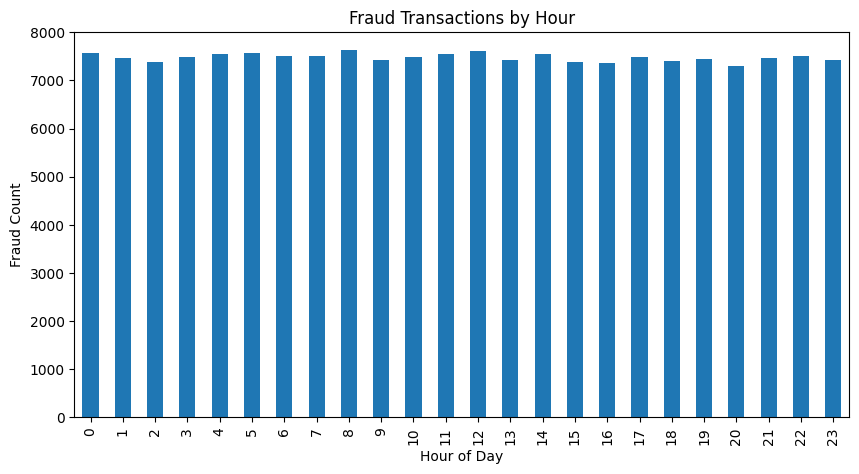

In [31]:
fraud_by_hour = df.groupby('hour')['is_fraud'].sum()

plt.figure(figsize=(10,5))
fraud_by_hour.plot(kind='bar')

plt.title('Fraud Transactions by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Fraud Count')

plt.show()

In [32]:
df['time_since_last_transaction'].isnull().sum()

np.int64(896513)

In [33]:
df['time_since_last_transaction'].describe()

count    4.103487e+06
mean     1.525799e+00
std      3.576569e+03
min     -8.777814e+03
25%     -2.562376e+03
50%      8.442747e-01
75%      2.568339e+03
max      8.757758e+03
Name: time_since_last_transaction, dtype: float64

In [34]:
(df['time_since_last_transaction'] < 0).sum()

np.int64(2051331)

In [35]:
pd.crosstab(
    df['time_since_last_transaction'].isnull(),
    df['is_fraud']
)

is_fraud,False,True
time_since_last_transaction,,
False,3923934,179553
True,896513,0


In [36]:
df.isnull().sum()

transaction_id                       0
timestamp                            0
sender_account                       0
receiver_account                     0
amount                               0
transaction_type                     0
merchant_category                    0
location                             0
device_used                          0
is_fraud                             0
fraud_type                     4820447
time_since_last_transaction     896513
spending_deviation_score             0
velocity_score                       0
geo_anomaly_score                    0
payment_channel                      0
ip_address                           0
device_hash                          0
hour                                 0
day_of_week                          0
month                                0
dtype: int64

In [37]:
df['fraud_type'] = df['fraud_type'].fillna('not_fraud')

In [38]:
df['fraud_type'].value_counts()

fraud_type
not_fraud           4820447
card_not_present     179553
Name: count, dtype: int64

In [39]:
df['time_missing_flag'] = df['time_since_last_transaction'].isnull().astype(int)

In [40]:
df['time_since_last_transaction'] = df['time_since_last_transaction'].fillna(0)

In [41]:
df.isnull().sum()

transaction_id                 0
timestamp                      0
sender_account                 0
receiver_account               0
amount                         0
transaction_type               0
merchant_category              0
location                       0
device_used                    0
is_fraud                       0
fraud_type                     0
time_since_last_transaction    0
spending_deviation_score       0
velocity_score                 0
geo_anomaly_score              0
payment_channel                0
ip_address                     0
device_hash                    0
hour                           0
day_of_week                    0
month                          0
time_missing_flag              0
dtype: int64

In [42]:
df.columns

Index(['transaction_id', 'timestamp', 'sender_account', 'receiver_account',
       'amount', 'transaction_type', 'merchant_category', 'location',
       'device_used', 'is_fraud', 'fraud_type', 'time_since_last_transaction',
       'spending_deviation_score', 'velocity_score', 'geo_anomaly_score',
       'payment_channel', 'ip_address', 'device_hash', 'hour', 'day_of_week',
       'month', 'time_missing_flag'],
      dtype='str')

In [43]:
df_ml = df.drop(
    columns=[
        'transaction_id',
        'sender_account',
        'receiver_account',
        'ip_address',
        'device_hash',
        'timestamp',
        'fraud_type'
    ]
)

In [44]:
df_ml.head()

,amount,transaction_type,merchant_category,location,device_used,is_fraud,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score,payment_channel,hour,day_of_week,month,time_missing_flag
0,343.78,withdrawal,utilities,Tokyo,mobile,False,0.0,-0.21,3,0.22,card,9,Tuesday,8,1
1,419.65,withdrawal,online,Toronto,atm,False,0.0,-0.14,7,0.96,ACH,1,Friday,8,1
2,2773.86,deposit,other,London,pos,False,0.0,-1.78,20,0.89,card,11,Friday,5,1
3,1666.22,deposit,online,Sydney,pos,False,0.0,-0.60,6,0.37,wire_transfer,6,Tuesday,10,1
4,24.43,transfer,utilities,Toronto,mobile,False,0.0,0.79,13,0.27,ACH,8,Sunday,9,1


In [45]:
df_ml.dtypes

amount                         float64
transaction_type                   str
merchant_category                  str
location                           str
device_used                        str
is_fraud                          bool
time_since_last_transaction    float64
spending_deviation_score       float64
velocity_score                   int64
geo_anomaly_score              float64
payment_channel                    str
hour                             int32
day_of_week                        str
month                            int32
time_missing_flag                int64
dtype: object

In [46]:
df_encoded = pd.get_dummies(
    df_ml,
    columns=[
        'transaction_type',
        'merchant_category',
        'location',
        'device_used',
        'payment_channel'
    ],
    drop_first=True

)

In [47]:
df_encoded.shape

(5000000, 33)

In [48]:
X = df_encoded.drop('is_fraud', axis=1)
y = df_encoded['is_fraud']

In [49]:
print(X.shape)
print(y.shape)

(5000000, 32)
(5000000,)


In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [51]:
print(X_train.shape)
print(X_test.shape)

(4000000, 32)
(1000000, 32)


In [52]:
X_train.memory_usage(deep=True).sum() / (1024**2)

np.float64(390.1109342575073)

In [53]:
df_encoded.shape

(5000000, 33)

In [54]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

In [57]:
y_pred = model.predict(X_test)

ValueError: could not convert string to float: 'Tuesday'

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

c:\Users\mkart\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mkart\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

       False       0.96      1.00      0.98    964089
        True       0.00      0.00      0.00     35911

    accuracy                           0.96   1000000
   macro avg       0.48      0.50      0.49   1000000
weighted avg       0.93      0.96      0.95   1000000



c:\Users\mkart\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
from sklearn.linear_model import LogisticRegression

model_balanced = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model_balanced.fit(X_train, y_train)

NameError: name 'X_train' is not defined

In [ ]:
y_pred_balanced = model_balanced.predict(X_test)
 

NameError: name 'model_balanced' is not defined

In [ ]:
%whos

Variable             Type                  Data/Info
----------------------------------------------------
LogisticRegression   type                  <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
df                   DataFrame             Shape: (5000000, 18)
model_balanced       LogisticRegression    LogisticRegression(class_<...>balanced', max_iter=1000)
pd                   module                <module 'pandas' from 'c:<...>es\\pandas\\__init__.py'>
plt                  module                <module 'matplotlib.pyplo<...>\\matplotlib\\pyplot.py'>
sns                  module                <module 'seaborn' from 'c<...>s\\seaborn\\__init__.py'>


In [ ]:
y_pred_balanced = model_balanced.predict(X_test)

NameError: name 'X_test' is not defined

In [ ]:
X = df_encoded.drop('is_fraud', axis=1)
y = df_encoded['is_fraud']

In [ ]:
df.columns

Index(['transaction_id', 'timestamp', 'sender_account', 'receiver_account',
       'amount', 'transaction_type', 'merchant_category', 'location',
       'device_used', 'is_fraud', 'fraud_type', 'time_since_last_transaction',
       'spending_deviation_score', 'velocity_score', 'geo_anomaly_score',
       'payment_channel', 'ip_address', 'device_hash'],
      dtype='str')

In [ ]:
df['fraud_type'] = df['fraud_type'].fillna('not_fraud')

In [ ]:
df['time_missing_flag'] = df['time_since_last_transaction'].isnull().astype(int)

In [ ]:
df['time_since_last_transaction'] = df['time_since_last_transaction'].fillna(0)

In [ ]:
df_ml = df.drop(
    columns=[
        'transaction_id',
        'sender_account',
        'receiver_account',
        'ip_address',
        'device_hash',
        'timestamp',
        'fraud_type'
    ]
)

In [ ]:
df_encoded = pd.get_dummies(
    df_ml,
    columns=[
        'transaction_type',
        'merchant_category',
        'location',
        'device_used',
        'payment_channel'
    ],
    drop_first=True
)

In [ ]:
df_encoded.shape

(5000000, 30)

In [ ]:
X = df_encoded.drop('is_fraud', axis=1)
y = df_encoded['is_fraud']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(4000000, 29)
(1000000, 29)


In [ ]:
pip install pyarrow

   ---------------------------------------- 0.0/27.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/27.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/27.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/27.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/27.3 MB 262.6 kB/s eta 0:01:44
   ---------------------------------------- 0.2/27.3 MB 1.2 MB/s eta 0:00:24
    --------------------------------------- 0.4/27.3 MB 2.2 MB/s eta 0:00:13
   - -------------------------------------- 1.0/27.3 MB 4.1 MB/s eta 0:00:07
   -- ------------------------------------- 1.4/27.3 MB 5.0 MB/s eta 0:00:06
   -- ------------------------------------- 1.8/27.3 MB 5.3 MB/s eta 0:00:05
   --- ------------------------------------ 2.1/27.3 MB 5.6 MB/s eta 0:00:05
   --- ------------------------------------ 2.5/27.3 MB 5.9 MB/s eta 0:00:05
   --- ------------------------------------ 2.7/27.3 MB 5.7 MB/s eta 0:00:05
   ---- -----------------


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
df_encoded.to_parquet('processed_fraud_data.parquet')

ArrowKeyError: No type extension with name arrow.py_extension_type found

In [ ]:
import xgboost as xgb
print(xgb.__version__)

3.2.0


In [ ]:
# Ensure xgboost is available in this notebook kernel
import sys
!{sys.executable} -m pip install xgboost

import xgboost as xgb
print("xgboost version:", xgb.__version__)

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


xgboost version: 3.2.0


In [ ]:
import xgboost as xgb
print(xgb.__version__)

3.2.0


In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

In [ ]:
xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [ ]:
y_pred_xgb = xgb_model.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_xgb))

c:\Users\mkart\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mkart\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

       False       0.96      1.00      0.98    964089
        True       0.00      0.00      0.00     35911

    accuracy                           0.96   1000000
   macro avg       0.48      0.50      0.49   1000000
weighted avg       0.93      0.96      0.95   1000000



c:\Users\mkart\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
y.value_counts(normalize=True)

is_fraud
False    0.964089
True     0.035911
Name: proportion, dtype: float64

In [ ]:
y_train.value_counts()

is_fraud
False    3856358
True      143642
Name: count, dtype: int64

In [ ]:
y_test.value_counts()

is_fraud
False    964089
True      35911
Name: count, dtype: int64

In [ ]:
y_pred_xgb.sum()

np.int64(0)

In [ ]:
y_prob = xgb_model.predict_proba(X_test)

y_prob[:10]

NameError: name 'X_test' is not defined

In [ ]:
y_prob[:,1].min(), y_prob[:,1].max()

(np.float32(2.680343e-06), np.float32(0.16674642))

In [ ]:
y_prob[:,1].mean()

np.float32(0.035937164)

In [ ]:
import numpy as np

y_pred_xgb_05 = (y_prob[:,1] >= 0.05).astype(int)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_xgb_05))

              precision    recall  f1-score   support

       False       0.96      0.99      0.98    964089
        True       0.05      0.01      0.02     35911

    accuracy                           0.96   1000000
   macro avg       0.50      0.50      0.50   1000000
weighted avg       0.93      0.96      0.94   1000000



In [ ]:
scale_pos_weight = 3856358 / 143642
print(scale_pos_weight)

26.847008535108117


In [ ]:
from xgboost import XGBClassifier

xgb_balanced = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=26.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_balanced.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [ ]:
y_pred_balanced_xgb = xgb_balanced.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_balanced_xgb))

              precision    recall  f1-score   support

       False       1.00      0.19      0.32    964089
        True       0.04      0.99      0.08     35911

    accuracy                           0.22   1000000
   macro avg       0.52      0.59      0.20   1000000
weighted avg       0.96      0.22      0.31   1000000



In [ ]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred_balanced_xgb))

[[185880 778209]
 [   299  35612]]


In [ ]:
fraud_index = y_test[y_test == True].index[0]

print("Actual:", y_test.loc[fraud_index])

xgb_balanced.predict(X_test.loc[[fraud_index]])

xgb_balanced.predict_proba(X_test.loc[[fraud_index]])

Actual: True


array([[0.45210397, 0.547896  ]], dtype=float32)

In [ ]:
fraud_index = y_test[y_test == True].index[0]

print("Actual:", y_test.loc[fraud_index])

print("Prediction:", xgb_balanced.predict(X_test.loc[[fraud_index]])[0])

print("Probability:", xgb_balanced.predict_proba(X_test.loc[[fraud_index]]))

Actual: True
Prediction: 1
Probability: [[0.45210397 0.547896  ]]


In [ ]:
y_prob = xgb_balanced.predict_proba(X_test)[:,1]

NameError: name 'xgb_balanced' is not defined

In [ ]:
from sklearn.metrics import precision_score, recall_score

thresholds = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50]

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    print(f"Threshold: {t}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print("-"*30)

Threshold: 0.05
Precision: 0.0437
Recall: 1.0000
------------------------------
Threshold: 0.1
Precision: 0.0437
Recall: 1.0000
------------------------------
Threshold: 0.2
Precision: 0.0437
Recall: 1.0000
------------------------------
Threshold: 0.3
Precision: 0.0437
Recall: 0.9999
------------------------------
Threshold: 0.4
Precision: 0.0437
Recall: 0.9995
------------------------------
Threshold: 0.5
Precision: 0.0438
Recall: 0.9917
------------------------------


In [ ]:
import pandas as pd

pd.Series(y_prob).describe()

NameError: name 'y_prob' is not defined

In [ ]:
from sklearn.metrics import precision_score, recall_score

thresholds = [0.55, 0.60, 0.65, 0.70]

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    print(f"Threshold: {t}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print("-"*30)

Threshold: 0.55
Precision: 0.0438
Recall: 0.5168
------------------------------
Threshold: 0.6
Precision: 0.0431
Recall: 0.0007
------------------------------
Threshold: 0.65
Precision: 0.1667
Recall: 0.0001
------------------------------
Threshold: 0.7
Precision: 0.5000
Recall: 0.0000
------------------------------


In [ ]:
from xgboost import XGBClassifier

xgb_5 = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=5,
    random_state=42,
    eval_metric='logloss'
)

xgb_5.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [ ]:
y_pred_5 = xgb_5.predict(X_test)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_5))

c:\Users\mkart\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

       False       0.96      1.00      0.98    964089
        True       0.00      0.00      0.00     35911

    accuracy                           0.96   1000000
   macro avg       0.48      0.50      0.49   1000000
weighted avg       0.93      0.96      0.95   1000000



c:\Users\mkart\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mkart\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
xgb_15 = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=15,
    random_state=42,
    eval_metric='logloss'
)

xgb_15.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [ ]:
y_pred_15 = xgb_15.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_15))

              precision    recall  f1-score   support

       False       0.96      1.00      0.98    964089
        True       0.09      0.00      0.00     35911

    accuracy                           0.96   1000000
   macro avg       0.53      0.50      0.49   1000000
weighted avg       0.93      0.96      0.95   1000000



In [ ]:
from sklearn.metrics import recall_score, precision_score

print("Precision:", precision_score(y_test, y_pred_15))
print("Recall:", recall_score(y_test, y_pred_15))

Precision: 0.08641975308641975
Recall: 0.00019492634568795075


In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_balanced.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance.head(15))

                          Feature  Importance
5               time_missing_flag    0.966980
19             location_Singapore    0.001365
8     transaction_type_withdrawal    0.001339
10       merchant_category_online    0.001288
11        merchant_category_other    0.001267
14       merchant_category_travel    0.001262
16                 location_Dubai    0.001234
28  payment_channel_wire_transfer    0.001226
7       transaction_type_transfer    0.001224
18              location_New York    0.001219
6        transaction_type_payment    0.001215
27           payment_channel_card    0.001200
23             device_used_mobile    0.001196
21                 location_Tokyo    0.001186
22               location_Toronto    0.001178


In [ ]:
pd.crosstab(
    df['time_missing_flag'],
    df['is_fraud'],
    normalize='index'
)

is_fraud,False,True
time_missing_flag,,
0,0.956244,0.043756
1,1.000000,0.000000


In [ ]:
X2 = X.drop('time_missing_flag', axis=1)

NameError: name 'X' is not defined

In [ ]:
X = df_encoded.drop('is_fraud', axis=1)
y = df_encoded['is_fraud']

NameError: name 'df_encoded' is not defined